<!-- <img src="../code/Resources/cropped-SummerWorkshop_Header.png">  -->

<h1 align="center">Workshop 1: Tutorial on behavioral states </h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 24th, 2026</h3> 
<h4 align="center">Day 2</h4> 

# intro 

# image

In [2]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb  


# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


##  Load the Dynamic Routing experiment from NWB

In [10]:
example_session_ids =  [
                        '668755_2023-08-31',  '759434_2025-02-04', '713655_2024-08-09', '664851_2023-11-13', '686740_2023-10-24' ,'742903_2024-10-22',\
                        '712815_2024-05-22', '743199_2024-12-05', '686176_2023-12-04', '702131_2024-02-26', '746439_2025-01-31', '667252_2023-09-26',\
                        ]

session_id = example_session_ids[2]
root = Path("/root/capsule/data/dynamicrouting_datacube")

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-07-24_13-26-26/713655_2024-08-09.nwb


In [11]:
# access the session data with pynwb
session = pynwb.NWBHDF5IO(nwb_path).read()


# Quick reference of the NWB file structure
# Important groups include: units, trials, intervals, and processing 
session

,timestamps
id,
0,NaN
1,14.17525
2,14.19192
3,14.20858
,timestamps
id,
0,NaN
1,14.40125
2,14.41791


In [14]:
# Get trials dataframe and look at a few rows
trials = session.trials[:]
trials.tail(7)

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
508,6158.82071,6164.35866,6158.82071,6160.28857,6160.330000,6160.830000,6160.40536,6161.32289,NaN,NaN,NaN,6161.350300,6164.386180,sound2,NaN,5,vis,508,82.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False,False
509,6165.22615,6170.76400,6165.22615,6166.71063,6166.771530,6167.271960,6166.82745,6167.74483,NaN,NaN,NaN,6167.772380,6170.791560,vis2,0.5,5,vis,509,83.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False
510,6174.28360,6179.82163,6174.28360,6175.76835,6175.809680,6176.309680,6175.88498,6176.80238,NaN,NaN,NaN,6176.829970,6179.849145,sound1,NaN,5,vis,510,84.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
511,6180.73900,6186.27699,6180.73900,6182.20691,6182.267840,6182.768277,6182.32372,6183.25784,6182.90753,6182.89689,6182.92426,6183.285355,6186.304570,vis1,0.0,5,vis,511,85.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
512,6187.89507,6193.43299,6187.89507,6189.36296,6189.423835,6189.940945,6189.47969,6190.41378,NaN,NaN,NaN,6190.441365,6193.460555,vis2,0.0,5,vis,512,86.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False
513,6194.06691,6199.62151,6194.06691,6195.55143,6195.612360,6196.112785,6195.66821,6196.58566,6196.13529,6196.13434,6196.15195,6196.613195,6199.649065,vis1,0.5,5,vis,513,87.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
514,6200.20533,6205.74332,6200.20533,6201.69007,6201.750830,6202.251240,6201.80676,6202.72414,NaN,NaN,NaN,6202.751670,6205.770870,vis2,0.0,5,vis,514,88.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False


## Mouse behavioral performance over the session

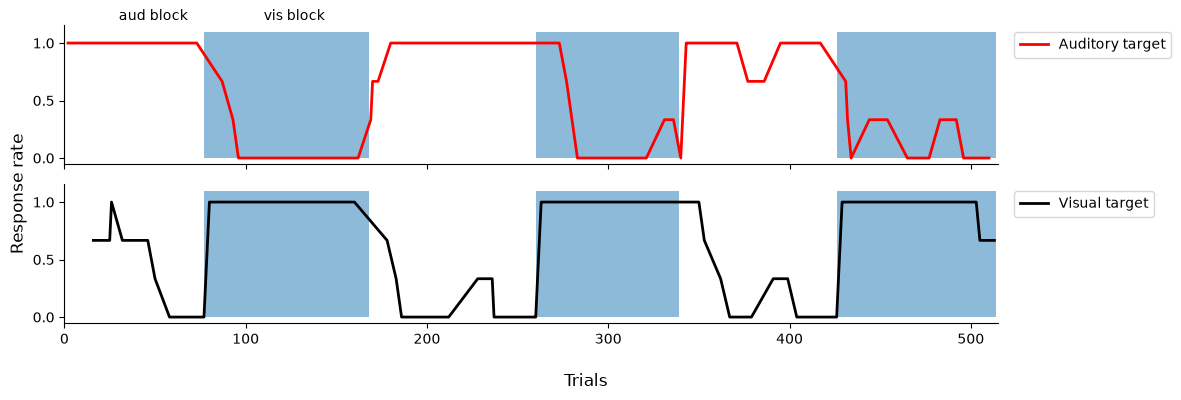

In [32]:
# response rates to target 
vis1_response_rate =  trials[trials.is_vis_target].is_response.rolling(3).mean()
sound1_response_rate = trials[trials.is_aud_target].is_response.rolling(3).mean()

fig, axs = plt.subplots(2, 1, figsize = (12, 4), sharex = True, sharey = True)
axs[0].plot(sound1_response_rate, color = 'r', lw = 2, label = 'Auditory target')
axs[1].plot(vis1_response_rate, color = 'k',  lw = 2, label = 'Visual target')

# add block information 
vis_block = trials.is_vis_rewarded
first_block = trials.iloc[0].rewarded_modality
for ax in axs: 
    ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5)
axs[0].text(30,  1.2, f"{first_block} block")
axs[0].text(110,  1.2, "vis block" if first_block == 'aud' else "aud block")


# formatting
for ax in axs: 
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(bbox_to_anchor = (1.01, 1.))
    ax.set_xlim(0, len(trials))
    ax.set_yticks([0, 0.5, 1])
fig.supxlabel('Trials')
fig.supylabel('Response rate')
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
The mouse is able to modulate its responses depending on the context block. They are changing their behavioral state. How can we identify these states?  
</div>

## 1. Identifying behavioral states based on visual inspection

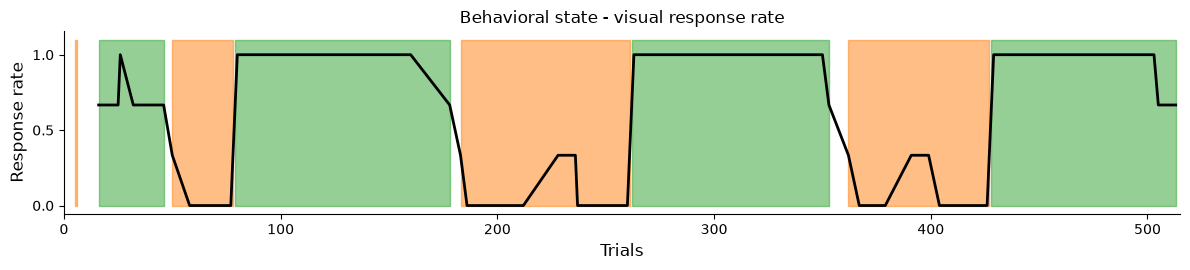

In [ ]:
# response rate thresholds for each modality
vis1_response_rate_threshold = 0.5
behavioral_state = vis1_response_rate > vis1_response_rate_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(vis1_response_rate, color = 'k',  lw = 2)
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:green')
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:orange')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Behavioral state - visual response rate", fontsize = 12)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate', fontsize = 12) 
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.1:</b> Using the code above, now evaluate behavioral states using auditory target response rates.
</p> </div>

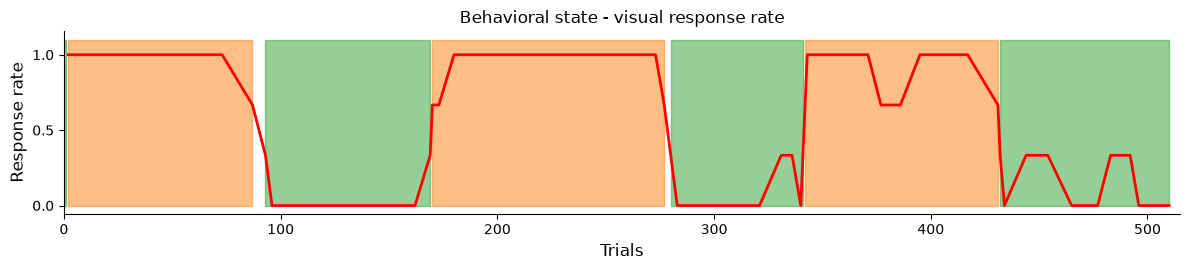

In [46]:
# response rate thresholds for each modality
sound1_response_rate_threshold = 0.5
behavioral_state = sound1_response_rate > vis1_response_rate_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(sound1_response_rate, color = 'r',  lw = 2)
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:green')
ax.fill_between(behavioral_state.index, 0, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Behavioral state - visual response rate", fontsize = 12)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate', fontsize = 12) 
plt.tight_layout()